# Task 7: Building an ML Pipeline

**NeuroFive ML Track, Week 4**

In Tasks 1 to 5 the Titanic work was spread across loose notebook cells: fill missing values here, encode categories there, split the data somewhere else. That works in a notebook, but it is fragile. Steps can be run out of order, applied to the wrong dataset, or accidentally skipped when the notebook is rerun.

A scikit-learn **Pipeline** packages every preprocessing step and the model itself into one object. That object can be fitted once, evaluated, saved to disk, and reused later on new data with a single call.

**What this notebook does**

1. Reproduces the manual Task 3 approach as a baseline.
2. Shows a real **data leakage** bug hiding in that manual approach.
3. Builds a proper Pipeline with `ColumnTransformer`, `StandardScaler`, and `OneHotEncoder`.
4. Adds four **engineered features** and tests whether they actually help.
5. Saves the final pipeline with **joblib** and reloads it to confirm it works.

In [1]:
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

## 1. Loading the Data

The dataset is loaded straight from the GitHub repository, so this notebook runs on a fresh Colab session with no file upload step.

In [2]:
url = "https://raw.githubusercontent.com/BadarRao/neurofive-ml-track/main/train.csv"
df = pd.read_csv(url)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 891
Columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
Age         177
Cabin       687
Embarked      2
dtype: int64


## 2. The Manual Approach, and the Bug Inside It

Here is the cleaning code from Tasks 2 and 3:

```python
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
```

It looks harmless, and it produced a working model. But look closely at **when** it runs: before `train_test_split`.

That means `df['Age'].median()` is calculated across **all 891 passengers**, including the 179 who will later become the test set. Information from the test set has flowed into the training data. This is called **data leakage**.

Why it matters: the test set is supposed to represent data the model has never encountered. If the test set influenced how the training data was prepared, the reported score is slightly optimistic, and the model will not perform quite as well on genuinely new passengers.

On Titanic the effect is small, because a median is a stable statistic and the split is random. On other problems, particularly with scaling or target-based encoding, leakage can inflate scores dramatically. A Pipeline prevents it structurally: the imputer is fitted only on the training fold, every single time.

In [4]:
# The manual approach, reproduced exactly as in Task 3 (leakage included)
df_manual = df.copy()

df_manual['Age'] = df_manual['Age'].fillna(df_manual['Age'].median())
df_manual['Embarked'] = df_manual['Embarked'].fillna(df_manual['Embarked'].mode()[0])
df_manual = df_manual.drop(columns=['Cabin'], errors='ignore')

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X_manual = df_manual[features]
y_manual = df_manual['Survived']

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_manual, y_manual, test_size=0.2, random_state=42, stratify=y_manual
)

manual_preprocessor = ColumnTransformer(transformers=[
    ('categorical', OneHotEncoder(handle_unknown='ignore'), ['Sex', 'Embarked']),
    ('numerical', 'passthrough', ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'])
])

manual_model = Pipeline(steps=[
    ('preprocessor', manual_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

manual_model.fit(Xm_train, ym_train)
manual_pred = manual_model.predict(Xm_test)

manual_accuracy = accuracy_score(ym_test, manual_pred)

print("Manual approach accuracy:", round(manual_accuracy, 4))
print("This should match the 0.8045 recorded in Task 3.")

Manual approach accuracy: 0.8045
This should match the 0.8045 recorded in Task 3.


## 3. Building the Pipeline Properly

Now the same problem, solved the professional way.

**The structure**

Two small pipelines feed into a `ColumnTransformer`, which feeds into the classifier:

- **Numerical branch:** `SimpleImputer(median)` then `StandardScaler()`
- **Categorical branch:** `SimpleImputer(most_frequent)` then `OneHotEncoder()`

Both imputers now live **inside** the pipeline, which is the whole point. When the pipeline is fitted, each imputer learns its median or mode from the training data only. When it later transforms the test set, it applies the value it already learned rather than recalculating. The leakage described above becomes structurally impossible.

**Why StandardScaler matters for the numerical branch:** `Fare` ranges from 0 to about 512, while `Pclass` only ranges from 1 to 3. Logistic Regression applies regularization that treats large coefficients as costly, so features on wildly different scales get penalized unevenly. Standardizing puts everything on a comparable footing.

In [5]:
# Raw features, with no manual cleaning applied at all.
# Every transformation is handled by the pipeline.
X = df[features]
y = df['Survived']

numerical_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Embarked']

print("Missing values still present in X:")
print(X.isnull().sum()[X.isnull().sum() > 0])

Missing values still present in X:
Age         177
Embarked      2
dtype: int64


In [6]:
# Numerical branch: fill gaps with the median, then standardize
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical branch: fill gaps with the most common value, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
])

# The complete pipeline: preprocessing plus model, as one object
pipeline_basic = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_basic

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline_basic.fit(X_train, y_train)
basic_pred = pipeline_basic.predict(X_test)

basic_accuracy = accuracy_score(y_test, basic_pred)

print("Manual approach accuracy:  ", round(manual_accuracy, 4))
print("Pipeline accuracy:         ", round(basic_accuracy, 4))
print("Difference:                ", round(basic_accuracy - manual_accuracy, 4))

Manual approach accuracy:   0.8045
Pipeline accuracy:          0.8045
Difference:                 0.0


### Confirming the pipeline holds up

The task asks for confirmation that the pipeline gives the same or better results than the manual approach. A single train/test split is a noisy way to check that, since the test set holds only 179 passengers and a couple of flipped predictions move the number visibly.

**Cross-validation** is the more reliable comparison. `cross_val_score` with 5 folds trains and evaluates five separate times on different slices of the data, then reports the average. Critically, the pipeline is refitted from scratch inside every fold, so imputation and scaling are relearned each time with no leakage.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_basic = cross_val_score(pipeline_basic, X, y, cv=cv, scoring='accuracy')

print("Cross-validation scores per fold:", np.round(cv_scores_basic, 4))
print()
print("Mean CV accuracy:", round(cv_scores_basic.mean(), 4))
print("Standard deviation:", round(cv_scores_basic.std(), 4))

Cross-validation scores per fold: [0.7709 0.8034 0.7921 0.7809 0.8202]

Mean CV accuracy: 0.7935
Standard deviation: 0.0172


The standard deviation is worth noting. It shows how much the score swings depending on which passengers land in the test fold, which is a good reminder that a difference of one or two percentage points between models on this dataset is usually noise rather than a real improvement.

## 4. Feature Engineering

Feature engineering means building new columns from existing ones, giving the model information that was present in the data but not in a form it could use.

**The four new features**

| Feature | Formula | Reasoning |
|---|---|---|
| `FamilySize` | `SibSp + Parch + 1` | The raw columns split family into siblings/spouses and parents/children. Total group size is the more meaningful quantity, and the `+ 1` counts the passenger themselves. |
| `IsAlone` | `FamilySize == 1` | Travelling alone is qualitatively different from travelling in a group, and that distinction is worth stating directly rather than making the model infer it. |
| `Title` | Extracted from `Name` | The `Name` column was discarded in earlier tasks as unusable text, but it contains Mr, Mrs, Miss, Master, and rarer titles. These carry age, sex, and social status in a single compact signal. Master in particular identifies young boys. |
| `FarePerPerson` | `Fare / FamilySize` | `Fare` is recorded per ticket, not per passenger, so a family of five sharing one ticket shows a high fare that overstates individual wealth. Dividing by group size corrects this. |

**A note on leakage:** every one of these is calculated row by row, using only values from that same passenger. No averages, medians, or other statistics across the dataset are involved, so computing them before the split is safe. If a feature required something like "average fare for this passenger's cabin deck," it would have to move inside the pipeline instead.

In [9]:
def engineer_features(data):
    """Create new features from existing columns. All operations are row-wise."""
    data = data.copy()

    # Total family members aboard, including the passenger
    data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

    # Travelling alone flag
    data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

    # Extract the title from the name, e.g. "Braund, Mr. Owen Harris" gives "Mr"
    data['Title'] = data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

    # Group the many rare titles into a single category
    common_titles = ['Mr', 'Mrs', 'Miss', 'Master']
    data['Title'] = data['Title'].apply(lambda t: t if t in common_titles else 'Rare')

    # Fare is per ticket, so divide by group size for a per-person figure
    data['FarePerPerson'] = data['Fare'] / data['FamilySize']

    return data


df_engineered = engineer_features(df)

print("Titles found:")
print(df_engineered['Title'].value_counts())

Titles found:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


In [10]:
print("Family size distribution:")
print(df_engineered['FamilySize'].value_counts().sort_index())
print()
print("Passengers travelling alone:", df_engineered['IsAlone'].sum(), "out of", len(df_engineered))

Family size distribution:
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

Passengers travelling alone: 537 out of 891


### Do the new features actually relate to survival?

Before adding them to the model, it is worth checking whether they show any signal at all.

In [11]:
print("Survival rate by title (%):")
print((df_engineered.groupby('Title')['Survived'].mean() * 100).round(2).to_string())
print()
print("Survival rate by family size (%):")
print((df_engineered.groupby('FamilySize')['Survived'].mean() * 100).round(2).to_string())
print()
print("Survival rate, alone vs with family (%):")
print((df_engineered.groupby('IsAlone')['Survived'].mean() * 100).round(2).to_string())

Survival rate by title (%):
Title
Master    57.50
Miss      69.78
Mr        15.67
Mrs       79.20
Rare      44.44

Survival rate by family size (%):
FamilySize
1     30.35
2     55.28
3     57.84
4     72.41
5     20.00
6     13.64
7     33.33
8      0.00
11     0.00

Survival rate, alone vs with family (%):
IsAlone
0    50.56
1    30.35


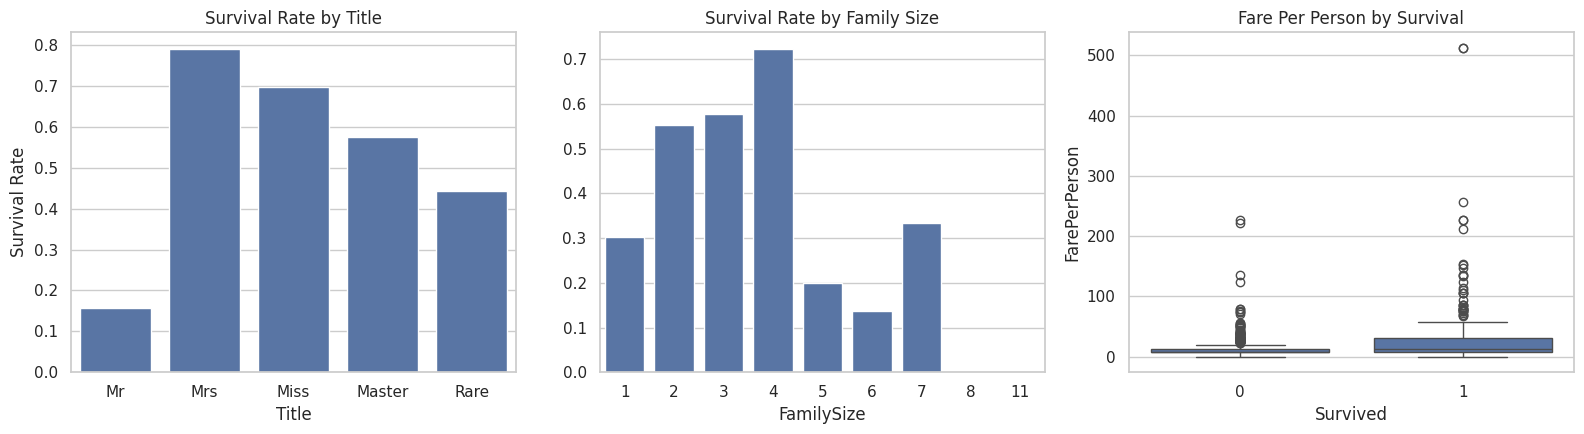

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.barplot(x='Title', y='Survived', data=df_engineered, errorbar=None, ax=axes[0])
axes[0].set_title('Survival Rate by Title')
axes[0].set_ylabel('Survival Rate')

sns.barplot(x='FamilySize', y='Survived', data=df_engineered, errorbar=None, ax=axes[1])
axes[1].set_title('Survival Rate by Family Size')
axes[1].set_ylabel('')

sns.boxplot(x='Survived', y='FarePerPerson', data=df_engineered, ax=axes[2])
axes[2].set_title('Fare Per Person by Survival')

plt.tight_layout()
plt.show()

Look at the family size chart in particular. The relationship is not a straight line: small groups tend to fare better than both solo travellers and very large families. A linear model cannot discover that shape from `SibSp` and `Parch` alone, which is exactly the kind of gap feature engineering exists to fill.

## 5. Testing Whether the New Features Help

The engineered features go into a second pipeline, built the same way. The comparison against the basic pipeline uses cross-validation, for the reasons given earlier.

In [13]:
features_engineered = [
    'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
    'FamilySize', 'IsAlone', 'Title', 'FarePerPerson'
]

X_eng = df_engineered[features_engineered]
y_eng = df_engineered['Survived']

numerical_features_eng = [
    'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
    'FamilySize', 'IsAlone', 'FarePerPerson'
]
categorical_features_eng = ['Sex', 'Embarked', 'Title']

print("Features before engineering:", len(features))
print("Features after engineering: ", len(features_engineered))

Features before engineering: 7
Features after engineering:  11


In [14]:
preprocessor_eng = ColumnTransformer(transformers=[
    ('numerical', numerical_transformer, numerical_features_eng),
    ('categorical', categorical_transformer, categorical_features_eng)
])

pipeline_engineered = Pipeline(steps=[
    ('preprocessor', preprocessor_eng),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

cv_scores_eng = cross_val_score(pipeline_engineered, X_eng, y_eng, cv=cv, scoring='accuracy')

print("Cross-validation scores per fold:", np.round(cv_scores_eng, 4))
print()
print("Mean CV accuracy:", round(cv_scores_eng.mean(), 4))
print("Standard deviation:", round(cv_scores_eng.std(), 4))

Cross-validation scores per fold: [0.838  0.8146 0.8258 0.8315 0.8315]

Mean CV accuracy: 0.8283
Standard deviation: 0.0078


In [15]:
comparison = pd.DataFrame({
    'Approach': [
        'Manual (Task 3 style)',
        'Pipeline, original features',
        'Pipeline, engineered features'
    ],
    'CV Mean Accuracy': [
        cross_val_score(manual_model, X_manual, y_manual, cv=cv, scoring='accuracy').mean(),
        cv_scores_basic.mean(),
        cv_scores_eng.mean()
    ],
    'CV Std Dev': [
        cross_val_score(manual_model, X_manual, y_manual, cv=cv, scoring='accuracy').std(),
        cv_scores_basic.std(),
        cv_scores_eng.std()
    ]
})

print(comparison.round(4).to_string(index=False))

                     Approach  CV Mean Accuracy  CV Std Dev
        Manual (Task 3 style)            0.7924      0.0174
  Pipeline, original features            0.7935      0.0172
Pipeline, engineered features            0.8283      0.0078


In [16]:
# Fit on the training split and evaluate on the held-out test set
X_eng_train, X_eng_test, y_eng_train, y_eng_test = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng
)

pipeline_engineered.fit(X_eng_train, y_eng_train)
eng_pred = pipeline_engineered.predict(X_eng_test)

print("Test set accuracy with engineered features:", round(accuracy_score(y_eng_test, eng_pred), 4))
print()
print(classification_report(y_eng_test, eng_pred, target_names=['Did Not Survive', 'Survived']))

Test set accuracy with engineered features: 0.8436

                 precision    recall  f1-score   support

Did Not Survive       0.85      0.90      0.88       110
       Survived       0.83      0.75      0.79        69

       accuracy                           0.84       179
      macro avg       0.84      0.83      0.83       179
   weighted avg       0.84      0.84      0.84       179



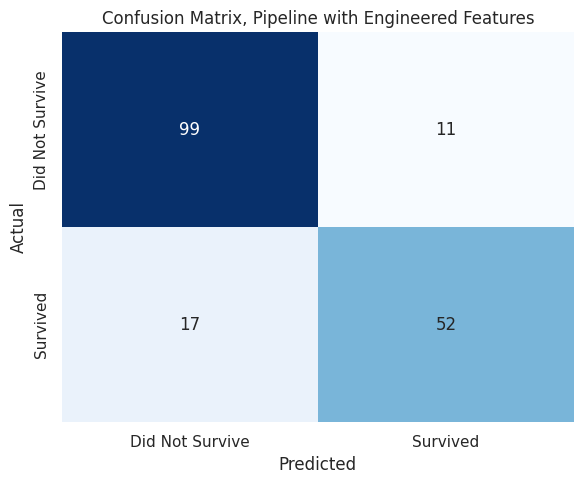

In [17]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_eng_test, eng_pred),
    annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['Did Not Survive', 'Survived'],
    yticklabels=['Did Not Survive', 'Survived']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix, Pipeline with Engineered Features')
plt.tight_layout()
plt.show()

### Reading the result honestly

Compare the three rows in the table above, but weigh them against the standard deviations rather than the means alone.

If the engineered pipeline improved by less than roughly one standard deviation, the honest conclusion is that the features did not clearly help on this dataset with this model, not that they are worthless. Logistic Regression is a linear model, and several of the new features carry information that overlaps with columns already present. A tree based model would likely make better use of `Title` and the non linear family size pattern.

Reporting a small gain as a real improvement is a common mistake. The purpose of running cross-validation here is to be able to tell the difference.

## 6. Saving the Pipeline with joblib

This is where the pipeline pays off. Because preprocessing and model live in one object, saving that object saves everything: the median learned by the imputer, the mean and standard deviation learned by the scaler, the category list learned by the encoder, and the fitted model coefficients.

Saving a bare model instead would be useless, since new raw data could not be transformed to match what the model expects.

**joblib rather than pickle:** joblib is the scikit-learn recommendation, because it stores large NumPy arrays more efficiently. The interface is otherwise nearly identical.

In [18]:
model_filename = 'titanic_pipeline.joblib'

joblib.dump(pipeline_engineered, model_filename)

print("Pipeline saved to:", model_filename)

Pipeline saved to: titanic_pipeline.joblib


In [19]:
# Reload it as a completely separate object
loaded_pipeline = joblib.load(model_filename)

loaded_pred = loaded_pipeline.predict(X_eng_test)

print("Original pipeline accuracy:", round(accuracy_score(y_eng_test, eng_pred), 4))
print("Reloaded pipeline accuracy:", round(accuracy_score(y_eng_test, loaded_pred), 4))
print()
print("Predictions identical:", np.array_equal(eng_pred, loaded_pred))

Original pipeline accuracy: 0.8436
Reloaded pipeline accuracy: 0.8436

Predictions identical: True


### Using the saved pipeline on brand new data

This is the real test. A new passenger arrives as raw, messy input: text categories, a missing age, no engineered columns. The saved pipeline handles all of it in one call.

In [20]:
new_passengers = pd.DataFrame({
    'PassengerId': [1001, 1002],
    'Name': ['Smith, Mr. John Edward', 'Brown, Miss. Emily Rose'],
    'Pclass': [3, 1],
    'Sex': ['male', 'female'],
    'Age': [np.nan, 28.0],          # deliberately missing, the imputer will handle it
    'SibSp': [0, 1],
    'Parch': [0, 2],
    'Fare': [7.25, 120.00],
    'Embarked': ['S', 'C']
})

print("Raw input:")
print(new_passengers.to_string(index=False))

Raw input:
 PassengerId                    Name  Pclass    Sex  Age  SibSp  Parch   Fare Embarked
        1001  Smith, Mr. John Edward       3   male  NaN      0      0   7.25        S
        1002 Brown, Miss. Emily Rose       1 female 28.0      1      2 120.00        C


In [21]:
# Apply the same engineering function, then predict
new_engineered = engineer_features(new_passengers)

predictions = loaded_pipeline.predict(new_engineered[features_engineered])
probabilities = loaded_pipeline.predict_proba(new_engineered[features_engineered])[:, 1]

for name, pred, prob in zip(new_passengers['Name'], predictions, probabilities):
    outcome = 'Survived' if pred == 1 else 'Did Not Survive'
    print(f"{name}: {outcome} (survival probability {prob:.2%})")

Smith, Mr. John Edward: Did Not Survive (survival probability 7.58%)
Brown, Miss. Emily Rose: Survived (survival probability 89.36%)


Note what did not happen. There was no manual median fill, no separate encoding step, and no scaling call. The missing age was imputed using the median learned during training, and every other transformation was applied in exactly the same order as it was during fitting. That consistency is the entire argument for pipelines.

In Colab, the saved `.joblib` file appears in the file panel on the left and can be downloaded from there.

## 7. Summary

**What was built**

1. A `ColumnTransformer` applying `StandardScaler` to numerical columns and `OneHotEncoder` to categorical columns, with imputation inside both branches.
2. A single `Pipeline` chaining that preprocessing to a Logistic Regression model.
3. Four engineered features: `FamilySize`, `IsAlone`, `Title`, and `FarePerPerson`.
4. A cross-validated comparison of the manual approach, the basic pipeline, and the engineered pipeline.
5. A saved artifact written with joblib, reloaded, and verified to produce identical predictions.

**Why the pipeline is better than the manual version**

- **No leakage.** Imputers and scalers are fitted on training data only, automatically, in every fold.
- **No ordering mistakes.** Steps cannot be run out of sequence or skipped on a rerun.
- **Reusable.** One `predict()` call handles raw input end to end.
- **Portable.** The whole thing is one file.
- **Tunable.** `GridSearchCV` can search across preprocessing and model parameters together, using the `step__parameter` syntax from Task 5.

**Limitations**

- Hyperparameters were left at defaults here to keep the comparison focused on pipeline structure and features. Combining this with the Task 5 tuning would be the natural next step.
- `Cabin` and `Ticket` were left unused. `Cabin` is missing for most passengers, but the deck letter can be extracted from those that have it.
- Only Logistic Regression was tested. The engineered features would likely help a tree based model more.